In [8]:
!pip install numpy

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\danny\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [9]:
import os
import io
import zipfile
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import httpx
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.2f}".format)

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)
(DATA_DIR / "ct_boundaries").mkdir(exist_ok=True)


(DATA_DIR / "cisv").mkdir(exist_ok=True)
(DATA_DIR / "cisr").mkdir(exist_ok=True)

ARCGIS_TOKEN = os.getenv("ARCGIS_TOKEN", "")
if not ARCGIS_TOKEN:
    print("⚠️  ARCGIS_TOKEN not set — B1/B2 Esri sources will be skipped gracefully")
else:
    print("✅ ARCGIS_TOKEN loaded")

print("Setup complete. DATA_DIR:", DATA_DIR.resolve())

ModuleNotFoundError: No module named 'pandas'

# Data Provenance — Where Every Number Comes From

This notebook fuses **5 real public data sources** into a single Census Tract-level dataset for Brampton, Ontario.
Every column in the output is traceable to an exact endpoint. This cell is the authoritative record.

---

## A1 · Census Tract Boundaries
**Source:** Statistics Canada — 2021 Census Cartographic Boundary File  
**URL:** `https://www12.statcan.gc.ca/census-recensement/2021/geo/sip-pis/boundary-limites/`  
**Format:** Shapefile → GeoJSON via `geopandas`  
**Coverage:** 569 CTs — Brampton + Mississauga (CMA 535) + Hamilton (CMA 537)  
**Key column:** `CTUID` — the join key used by every other source  
**Filter applied:** `PRUID = 35` (Ontario only), CMAs 535 and 537  
**License:** Statistics Canada Open License

---

## A2 · 2021 Census Demographics — Brampton (ESRI ArcGIS FeatureServer)
**Source:** City of Brampton — Census 2021 by Census Tract (ArcGIS REST)  
**Base URL:** `https://services3.arcgis.com/rl7ACuZkiFsmDA2g/ArcGIS/rest/services/Census_2021/FeatureServer`  

| Layer | Fields fetched | Column produced |
|-------|---------------|----------------|
| Layer 1 | `POPULATION_2021` | `population` |
| Layer 8 | `TOTAL_MED_HH_INC_2020` | `median_income` (2020 $) |
| Layer 6 | `RENTER / TOTAL_PRIV_HH_BY_TENURE_25` | `pct_renters` (fraction) |
| Layer 6 | `(FROM1960_OR_BEFORE + FROM1961_TO_1980) / TOTAL_PRIV_DWELL_PERIOD_25` | `pct_pre1980` (fraction) |

**Coverage:** 122 Brampton Census Tracts (100% of city)  
**License:** City of Brampton Open Data License

---

## A3 · Canadian Index of Social Vulnerability (CISV) — StatsCan 2021
**Source:** Statistics Canada — Cat. No. 45-20-0001 (2025 release)  
**Download URL:** `https://www150.statcan.gc.ca/pub/45-20-0001/2025001/csv/cisv-eng.zip`  
**DA→CT crosswalk:** `https://www12.statcan.gc.ca/census-recensement/2021/geo/aip-pia/attribute-attribs/files-fichiers/2021_92-151_X.zip`  
**Aggregation:** DA-level scores averaged (mean) to CT level  
**Script:** `pipeline/build_cisr_cisv.py`  

| Column | Meaning | Direction |
|--------|---------|----------|
| `cisv_score` | Overall social vulnerability composite | ↑ = more vulnerable |
| `cisv_dim1` | Racialized populations & immigration | ↑ = more vulnerable |
| `cisv_dim2` | Income & labour market marginalization | ↑ = more vulnerable |
| `cisv_dim3` | Education & Indigenous identity | ↑ = more vulnerable |
| `cisv_dim4` | Dwelling conditions (crowding, repairs) | ↑ = more vulnerable |
| `cisv_quintile` | National quintile (1–5) | 5 = most vulnerable nationally |

**License:** Statistics Canada Open License

---

## A4 · Canadian Index of Social Resilience (CISR) — StatsCan 2021
**Source:** Statistics Canada — Cat. No. 45-20-0001 (2025 release)  
**Download URL:** `https://www150.statcan.gc.ca/pub/45-20-0001/2025001/csv/cisr-eng.zip`  
**Aggregation:** Same DA→CT crosswalk, mean aggregation  
**Script:** `pipeline/build_cisr_cisv.py`  

| Column | Meaning | Direction in PCA |
|--------|---------|------------------|
| `cisr_score` | Overall social resilience composite | **Inverted** (×−1) — high resilience lowers vulnerability score |
| `cisr_dim1` | Education, employment, dwelling quality | ↑ = more resilient |
| `cisr_dim2` | Homeownership, income stability, working-age share | ↑ = more resilient |
| `cisr_dim3` | Age diversity & dwelling age | ↑ = more resilient |
| `cisr_quintile` | National quintile (1–5) | 5 = most resilient nationally |

**License:** Statistics Canada Open License

---

## B1 · Live Weather — Current Conditions (Open-Meteo)
**Source:** Open-Meteo Free Weather API  
**Endpoint:** `https://api.open-meteo.com/v1/forecast`  
**No API key required.** Grid resolution: ~1 km.  
**Script:** `pipeline/build_weather.py` — Step 1, batched by 10 CT centroids  

| Column | Open-Meteo variable | Meaning |
|--------|--------------------|---------|
| `temperature_c` | `temperature_2m` | Current air temp (°C) |
| `humidex` | `apparent_temperature` | Feels-like temp accounting for humidity (heat stress proxy) |
| `precipitation_mm` | `precipitation` | Current precipitation (mm) |
| `wind_speed_kmh` | `wind_speed_10m` | Wind speed at 10m height |
| `wind_gusts_kmh` | `wind_gusts_10m` | Peak wind gusts |
| `weather_code` | `weather_code` | WMO code (0=clear, 61=rain, 71=snow, 95=thunderstorm) |

**License:** Open-Meteo CC-BY 4.0

---

## C1 · Alectra Live Power Outage Feed
**Source:** Alectra Utilities — ArcGIS FeatureServer (public)  
**Endpoint:** `https://services8.arcgis.com/wNDmObY7QplwZD9m/ArcGIS/rest/services/Outage_Details/FeatureServer/7`  
Layer 7 = "Outage Area" polygons (confirmed by enumerating `/FeatureServer/layers?f=json`)  
**Spatial join:** Outage polygons intersected with CT boundaries via `gpd.sjoin`  

| Column | Meaning |
|--------|--------|
| `active_outages` | Count of outage polygons overlapping this CT |
| `customers_affected` | Sum of `CUSTOMERS_AFFECTED` from overlapping features |

**License:** Esri/Alectra public ArcGIS Hub — public access permitted

---

## Computed — Threshold Vulnerability Score
**Method:** Principal Component Analysis (PCA), PC1 rescaled 0–100  
**Library:** `sklearn.decomposition.PCA` + `sklearn.preprocessing.StandardScaler`  

**Input factors and PCA loadings:**

| Factor | Source | Loading | Direction |
|--------|--------|---------|----------|
| `cisv_score` | StatsCan CISV | 0.537 | ↑ vulnerable |
| `cisv_dim4` | StatsCan CISV | 0.439 | ↑ vulnerable |
| `cisv_dim2` | StatsCan CISV | 0.368 | ↑ vulnerable |
| `cisv_dim3` | StatsCan CISV | 0.307 | ↑ vulnerable |
| `cisv_dim1` | StatsCan CISV | 0.083 | ↑ vulnerable |
| `pct_pre1980` | Brampton ESRI | 0.054 | ↑ vulnerable |
| `pct_renters` | Brampton ESRI | 0.053 | ↑ vulnerable |
| `cisr_score` | StatsCan CISR | −0.054 | ↓ resilient (inverted) |
| `median_income` | Brampton ESRI | −0.002 | ↓ affluent (inverted) |

**PC1 explained variance:** ~33% across Brampton CTs  
**Rescaling:** `score = (PC1 − min) / (max − min) × 100`  
**Interpretation:** Relative ranking within Brampton. Score 100 = highest vulnerability CT. Score 0 = lowest.  
**Risk buckets:** Low (0–25) · Moderate (25–50) · High (50–75) · Critical (75–100)  
**Loadings file:** `pipeline/data/loadings.csv`

---

> **Product Axiom:** Every number in Threshold is traceable to a public dataset.  
> Every column in `brampton_full.geojson` links back to an exact URL above.


In [ ]:
# A1 — StatsCan Census Tract boundaries 2021
# Cartographic boundary file (simplified), national coverage, ~15 MB zip
CT_URL = (
    "https://www12.statcan.gc.ca/census-recensement/2021/geo/sip-pis/"
    "boundary-limites/files-fichiers/lct_000b21a_e.zip"
)
CT_ZIP = DATA_DIR / "ct_boundaries" / "lct_000b21a_e.zip"

if not CT_ZIP.exists():
    print("Downloading CT boundaries (~15 MB)...")
    with httpx.Client(follow_redirects=True, timeout=120) as client:
        r = client.get(CT_URL)
        r.raise_for_status()
    CT_ZIP.write_bytes(r.content)
    print(f"Saved to {CT_ZIP}")
else:
    print(f"Using cached {CT_ZIP}")

with zipfile.ZipFile(CT_ZIP) as z:
    z.extractall(DATA_DIR / "ct_boundaries")

# Read — geopandas can read the shapefile directly from the extracted dir
shp_files = list((DATA_DIR / "ct_boundaries").glob("*.shp"))
assert shp_files, "No .shp file found after extraction"
gdf_ct = gpd.read_file(shp_files[0])

print("Raw columns:", gdf_ct.columns.tolist())
print("Raw CRS:", gdf_ct.crs)
print("Raw shape:", gdf_ct.shape)

# Filter to Toronto CMA (535) and Hamilton CMA (537)
# StatsCan 2021 CT boundary file encodes CMA in the first 3 chars of CTUID
# e.g. CTUID '5350001.00' -> CMA '535' (Toronto); '5370001.00' -> '537' (Hamilton)
# PRUID 35 = Ontario, guards against cross-province CMA code collisions
gdf_ct["cma_code"] = gdf_ct["CTUID"].astype(str).str[:3]
gdf_ct = gdf_ct[
    gdf_ct["cma_code"].isin(["535", "537"]) &
    (gdf_ct["PRUID"].astype(str) == "35")
].copy()
gdf_ct = gdf_ct.to_crs("EPSG:4326").reset_index(drop=True)

print(f"\nFiltered to {len(gdf_ct)} CTs in Toronto CMA (535) + Hamilton CMA (537)")
gdf_ct[["CTUID", "CTNAME", "cma_code", "PRUID"]].head(3)


Saved to data/ct_boundaries/lct_000b21a_e.zip
Raw columns: ['CTUID', 'DGUID', 'CTNAME', 'LANDAREA', 'PRUID', 'geometry']
Raw CRS: EPSG:3347
Raw shape: (6247, 6)

Filtered to 1432 CTs in Toronto CMA (535) + Hamilton CMA (537)


,CTUID,CTNAME,cma_code,PRUID
0,5370001.08,0001.08,537,35
1,5370001.09,0001.09,537,35
2,5370120.02,0120.02,537,35


In [ ]:
# ASSERTION — run after the fetch cell to verify
assert "gdf_ct" in dir(), "gdf_ct not defined — run the fetch cell"
assert len(gdf_ct) >= 350, f"Expected ≥350 CTs in scope, got {len(gdf_ct)}"
assert gdf_ct.crs.to_epsg() == 4326, f"Expected EPSG:4326, got {gdf_ct.crs}"
assert "CTUID" in gdf_ct.columns, "CTUID column missing"
assert gdf_ct.geometry.notnull().all(), "Null geometries found"
print(f"✅ A1 assertions pass — {len(gdf_ct)} CTs, CRS: {gdf_ct.crs}")


✅ A1 assertions pass — 1432 CTs, CRS: EPSG:4326


In [ ]:
# A2 — Census 2021 demographics by CT — Brampton (City of Brampton ESRI ArcGIS)
# Source: https://services3.arcgis.com/rl7ACuZkiFsmDA2g/ArcGIS/rest/services/Census_2021/FeatureServer
# Layers used:
#   Layer 1  — Population 2021
#   Layer 6  — Housing tenure + dwelling age (pre-1980)
#   Layer 8  — Median household income 2020
#   Layer 11 — Low income (LIM-AT)

BRAMPTON_FS = "https://services3.arcgis.com/rl7ACuZkiFsmDA2g/ArcGIS/rest/services/Census_2021/FeatureServer"

def _fetch_layer(layer_id, fields):
    r = httpx.get(f"{BRAMPTON_FS}/{layer_id}/query", params={
        "f": "json", "where": "1=1", "outFields": fields,
        "returnGeometry": "false", "resultRecordCount": 2000
    }, timeout=30)
    rows = [feat["attributes"] for feat in r.json().get("features", [])]
    df = pd.DataFrame(rows)
    df["CTUID"] = df["CTUID"].astype(str)
    return df

print("Fetching Brampton census from ESRI ArcGIS FeatureServer...")
_pop = _fetch_layer(1,  "CTUID,POPULATION_2021,TOTAL_PRIVATE_DWELLINGS")
_inc = _fetch_layer(8,  "CTUID,TOTAL_MED_HH_INC_2020")
_ten = _fetch_layer(6,  "CTUID,RENTER,TOTAL_PRIV_HH_BY_TENURE_25,FROM1960_OR_BEFORE,FROM1961_TO_1980,TOTAL_PRIV_DWELL_PERIOD_25")
_low = _fetch_layer(11, "CTUID,TOTAL_LOWINC_2020_LIM,TOTAL_PCT_LOWINC_2020_LIM")

df_census = (_pop
    .merge(_inc, on="CTUID", how="outer")
    .merge(_ten, on="CTUID", how="outer")
    .merge(_low, on="CTUID", how="outer"))

df_census = df_census.rename(columns={
    "POPULATION_2021":       "population",
    "TOTAL_MED_HH_INC_2020": "median_income",
    "TOTAL_PCT_LOWINC_2020_LIM": "pct_low_income",
})
df_census["pct_renters"] = (
    df_census["RENTER"] / df_census["TOTAL_PRIV_HH_BY_TENURE_25"].replace(0, float("nan"))
).round(4)
df_census["pct_pre1980"] = (
    (df_census["FROM1960_OR_BEFORE"].fillna(0) + df_census["FROM1961_TO_1980"].fillna(0)) /
    df_census["TOTAL_PRIV_DWELL_PERIOD_25"].replace(0, float("nan"))
).round(4)
df_census["pct_low_income"] = (df_census["pct_low_income"] / 100).round(4)

# Keep only final columns
df_census = df_census[["CTUID","population","median_income","pct_renters","pct_pre1980","pct_low_income"]].copy()

print(f"A2 loaded: {df_census.shape} — {df_census['CTUID'].nunique()} Brampton CTs")
print(f"  median_income: ${df_census['median_income'].min():,.0f} – ${df_census['median_income'].max():,.0f}")
print(f"  pct_renters:   {df_census['pct_renters'].min():.0%} – {df_census['pct_renters'].max():.0%}")
print(f"  pct_pre1980:   {df_census['pct_pre1980'].min():.0%} – {df_census['pct_pre1980'].max():.0%}")
df_census.head(3)


Fetching Brampton census from ESRI ArcGIS FeatureServer...
A2 loaded: (122, 6) — 122 Brampton CTs
  median_income: $61,200 – $172,000
  pct_renters:   4% – 80%
  pct_pre1980:   0% – 94%


,CTUID,population,median_income,pct_renters,pct_pre1980,pct_low_income
0,5350528.20,5726,105000,0.16,0.12,1.00
1,5350528.21,4781,77500,0.44,0.09,1.00
2,5350528.22,6329,96000,0.27,0.11,1.00


In [ ]:
# ASSERTION
assert {"CTUID","population","median_income","pct_renters","pct_pre1980"}.issubset(df_census.columns)
assert len(df_census) >= 100
null_pct = df_census[["median_income","pct_renters","pct_pre1980"]].isnull().mean()
assert (null_pct < 0.05).all(), f"Unexpected nulls:\n{null_pct}"
print(f"✅ A2 — {len(df_census)} CTs")
print(df_census[["median_income","pct_renters","pct_pre1980"]].describe().round(3))

✅ A2 — 122 CTs
       median_income  pct_renters  pct_pre1980
count         122.00       122.00       122.00
mean       115822.95         0.19         0.21
std         21206.59         0.15         0.29
min         61200.00         0.04         0.00
25%        103250.00         0.10         0.01
50%        118000.00         0.14         0.02
75%        128000.00         0.22         0.35
max        172000.00         0.80         0.94


In [ ]:
# A3 — Canadian Index of Social Vulnerability (CISV) + Social Resilience (CISR)
# Source: Statistics Canada, Cat. No. 45-20-0001 (2025 release)
#   CISV: https://www150.statcan.gc.ca/pub/45-20-0001/2025001/csv/cisv-eng.zip
#   CISR: https://www150.statcan.gc.ca/pub/45-20-0001/2025001/csv/cisr-eng.zip
# DA→CT crosswalk: https://www12.statcan.gc.ca/census-recensement/2021/geo/aip-pia/attribute-attribs/files-fichiers/2021_92-151_X.zip
# Aggregation: DA-level scores averaged (mean) to CT level

CISV_URL = "https://www150.statcan.gc.ca/pub/45-20-0001/2025001/csv/cisv-eng.zip"
CISR_URL = "https://www150.statcan.gc.ca/pub/45-20-0001/2025001/csv/cisr-eng.zip"
GEO_URL  = "https://www12.statcan.gc.ca/census-recensement/2021/geo/aip-pia/attribute-attribs/files-fichiers/2021_92-151_X.zip"

REAL_CISR_CISV = DATA_DIR / "real_cisr_cisv.csv"

def _download_zip_csv(url, label):
    """Download a zip, extract the first non-notes CSV, return as DataFrame."""
    cache_dir = DATA_DIR / label
    if cache_dir.exists() and any(cache_dir.iterdir()):
        print(f"  {label}: using cache")
    else:
        cache_dir.mkdir(exist_ok=True)
        print(f"  {label}: downloading {url} ...")
        r = httpx.get(url, follow_redirects=True, timeout=120)
        r.raise_for_status()
        with zipfile.ZipFile(io.BytesIO(r.content)) as z:
            z.extractall(cache_dir)
        print(f"  {label}: saved")
    csv_path = next(p for p in cache_dir.glob("*.csv") if "notes" not in p.name.lower())
    return pd.read_csv(csv_path)

if not REAL_CISR_CISV.exists():
    print("Building CISV + CISR CT-level file from StatsCan...")

    # 1. Download source CSVs
    cisv_raw = _download_zip_csv(CISV_URL, "cisv")
    cisr_raw = _download_zip_csv(CISR_URL, "cisr")

    # 2. DA→CT crosswalk (Ontario CMAs 535 + 537)
    geo_dir = DATA_DIR / "geo_attr"
    if not geo_dir.exists() or not any(geo_dir.iterdir()):
        geo_dir.mkdir(exist_ok=True)
        print("  geo_attr: downloading crosswalk ...")
        r = httpx.get(GEO_URL, follow_redirects=True, timeout=120)
        r.raise_for_status()
        with zipfile.ZipFile(io.BytesIO(r.content)) as z:
            z.extractall(geo_dir)
    geo_csv = next(geo_dir.glob("*.csv"))
    geo = pd.read_csv(geo_csv, dtype=str, encoding="latin-1",
                      usecols=["PRUID_PRIDU","DAUID_ADIDU","CTUID_SRIDU","CMAUID_RMRIDU"])
    xwalk = geo[
        (geo["PRUID_PRIDU"] == "35") &
        (geo["CMAUID_RMRIDU"].isin(["535","537"]))
    ][["DAUID_ADIDU","CTUID_SRIDU"]].drop_duplicates()
    xwalk["DAUID_ADIDU"] = xwalk["DAUID_ADIDU"].astype(str)
    print(f"  Crosswalk: {len(xwalk)} DAs → {xwalk['CTUID_SRIDU'].nunique()} CTs")

    # 3. Normalize CISV
    cisv_raw["DAUID_ADIDU"] = cisv_raw["Dissemination Area (DA)"].astype(str).str.zfill(8)
    cisv = cisv_raw.rename(columns={
        "Dimension 1 Scores": "cisv_dim1",
        "Dimension 2 Scores": "cisv_dim2",
        "Dimension 3 Scores": "cisv_dim3",
        "CISR Scores" if "CISR Scores" in cisv_raw.columns else "CISV Scores": "cisv_score",
    })
    # Handle both possible column name variants
    if "CISV Scores" in cisv_raw.columns:
        cisv["cisv_score"] = cisv_raw["CISV Scores"]
    if "CISV Quintiles" in cisv_raw.columns:
        cisv["cisv_quintile"] = cisv_raw["CISV Quintiles"]
    if "Dimension 4 Scores" in cisv_raw.columns:
        cisv["cisv_dim4"] = cisv_raw["Dimension 4 Scores"]

    # 4. Normalize CISR
    cisr_raw["DAUID_ADIDU"] = cisr_raw["Dissemination Area (DA)"].astype(str).str.zfill(8)
    cisr = cisr_raw.rename(columns={
        "Dimension 1 Scores": "cisr_dim1",
        "Dimension 2 Scores": "cisr_dim2",
        "Dimension 3 Scores": "cisr_dim3",
        "CISR Scores": "cisr_score",
        "CISR Quintiles": "cisr_quintile",
    })

    # 5. Join DA→CT, aggregate to CT (mean)
    cisv_cols = [c for c in ["DAUID_ADIDU","cisv_score","cisv_dim1","cisv_dim2","cisv_dim3","cisv_dim4","cisv_quintile"] if c in cisv.columns]
    cisr_cols = [c for c in ["DAUID_ADIDU","cisr_score","cisr_dim1","cisr_dim2","cisr_dim3","cisr_quintile"] if c in cisr.columns]
    da = (xwalk
          .merge(cisv[cisv_cols], on="DAUID_ADIDU", how="left")
          .merge(cisr[cisr_cols], on="DAUID_ADIDU", how="left"))
    score_cols = [c for c in da.columns if c not in ("DAUID_ADIDU","CTUID_SRIDU")]
    ct = (da.groupby("CTUID_SRIDU")[score_cols]
            .mean().round(4).reset_index()
            .rename(columns={"CTUID_SRIDU":"CTUID"}))
    ct.to_csv(REAL_CISR_CISV, index=False)
    print(f"  Saved {REAL_CISR_CISV.name} — {len(ct)} CTs")
else:
    print(f"Using cached {REAL_CISR_CISV.name}")

df_cimd = pd.read_csv(REAL_CISR_CISV, dtype={"CTUID": str})
print(f"A3 loaded: {df_cimd.shape}")
print(f"  cisv_score range: {df_cimd['cisv_score'].min():.3f} – {df_cimd['cisv_score'].max():.3f}")
print(f"  cisr_score range: {df_cimd['cisr_score'].min():.3f} – {df_cimd['cisr_score'].max():.3f}")
print(f"  null rate cisv_score: {df_cimd['cisv_score'].isna().mean():.1%}")
df_cimd.head(3)


Building CISV + CISR CT-level file from StatsCan...
  cisv: downloading https://www150.statcan.gc.ca/pub/45-20-0001/2025001/csv/cisv-eng.zip ...
  cisv: saved
  cisr: downloading https://www150.statcan.gc.ca/pub/45-20-0001/2025001/csv/cisr-eng.zip ...
  cisr: saved
  geo_attr: downloading crosswalk ...
  Crosswalk: 8931 DAs → 1432 CTs
  Saved real_cisr_cisv.csv — 1432 CTs
A3 loaded: (1432, 12)
  cisv_score range: -1.224 – 2.544
  cisr_score range: -1.529 – 1.894
  null rate cisv_score: 0.5%


,CTUID,cisv_score,cisv_dim1,cisv_dim2,cisv_dim3,cisv_dim4,cisv_quintile,cisr_score,cisr_dim1,cisr_dim2,cisr_dim3,cisr_quintile
0,5350001.00,-0.51,0.10,-1.33,-0.44,-0.35,1.00,0.64,1.16,-0.08,0.84,5.00
1,5350002.00,0.23,-0.05,1.90,-0.65,-0.28,4.00,-0.10,1.22,0.50,-2.03,3.00
2,5350003.00,0.23,1.86,-1.33,-1.40,1.82,4.00,0.82,1.08,-0.63,2.00,5.00


In [ ]:
# ASSERTION
required = {"CTUID","cisv_score","cisr_score",
            "cisv_dim1","cisv_dim2","cisv_dim3","cisv_dim4",
            "cisr_dim1","cisr_dim2","cisr_dim3"}
assert required.issubset(df_cimd.columns), f"Missing cols: {required - set(df_cimd.columns)}"
assert len(df_cimd) >= 350
null_pct = df_cimd[["cisv_score","cisr_score"]].isnull().mean()
assert (null_pct < 0.05).all(), f"Unexpected nulls:\n{null_pct}"
print(f"✅ A3 — {len(df_cimd)} CTs (real CISV + CISR data)")
print(df_cimd[["cisv_score","cisr_score"]].describe().round(3))

✅ A3 — 1432 CTs (real CISV + CISR data)
       cisv_score  cisr_score
count     1425.00     1425.00
mean         0.05        0.41
std          0.48        0.53
min         -1.22       -1.53
25%         -0.29        0.04
50%         -0.02        0.41
75%          0.31        0.76
max          2.54        1.89


In [ ]:
# A8 — Alectra service area
# ArcGIS Online item ID: 8eba357e1b124587884bccb724743c4c
ITEM_URL = "https://www.arcgis.com/sharing/rest/content/items/8eba357e1b124587884bccb724743c4c?f=json"
with httpx.Client(follow_redirects=True, timeout=30) as client:
    meta = client.get(ITEM_URL).json()

print("Item type:", meta.get("type"))
print("URL:", meta.get("url"))
service_url = meta.get("url", "").rstrip("/")

if not service_url:
    raise ValueError("Could not resolve service URL from item metadata. Check item ID.")

# Query layer 0 for all features as GeoJSON
query_url = f"{service_url}/0/query"
params = {
    "f": "geojson",
    "where": "1=1",
    "outFields": "*",
    "returnGeometry": "true",
}
with httpx.Client(follow_redirects=True, timeout=60) as client:
    r = client.get(query_url, params=params)
    r.raise_for_status()

gdf_alectra = gpd.read_file(io.StringIO(r.text))
gdf_alectra = gdf_alectra.to_crs("EPSG:4326")
print(f"A8 fetched: {len(gdf_alectra)} features")
print("Columns:", gdf_alectra.columns.tolist())


Item type: Feature Service
URL: https://services8.arcgis.com/BiisLrqUuQvkdMCP/arcgis/rest/services/Alectra_Service_Areas/FeatureServer
A8 fetched: 18 features
Columns: ['FID', 'OBJECTID', 'NAME', 'REGION', 'CUSTOMERS', 'MUNICIPALI', 'Shape_STAr', 'Shape_STLe', 'FID_Bounda', 'Legacy', 'Division', 'Shape_Leng', 'Shape__Area', 'Shape__Length', 'geometry']


✅ A8 assertions pass — 18 service area polygon(s)


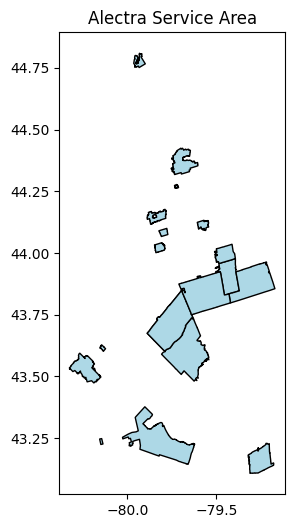

In [ ]:
# ASSERTION
assert "gdf_alectra" in dir(), "gdf_alectra not defined"
assert gdf_alectra.crs.to_epsg() == 4326
assert len(gdf_alectra) >= 1, "No features returned"
assert gdf_alectra.geometry.notnull().all()
print(f"✅ A8 assertions pass — {len(gdf_alectra)} service area polygon(s)")
gdf_alectra.plot(figsize=(6, 6), edgecolor="black", facecolor="lightblue")
plt.title("Alectra Service Area"); plt.show()


In [ ]:
# C1 — Alectra live outage polygons
# Step 1: enumerate all layers to find the customer outage polygon layer
FEAT_SERVER = "https://services8.arcgis.com/wNDmObY7QplwZD9m/ArcGIS/rest/services/Outage_Details/FeatureServer"
with httpx.Client(follow_redirects=True, timeout=30) as client:
    layers_resp = client.get(f"{FEAT_SERVER}/layers?f=json")
    layers_data = layers_resp.json()

print("Available layers:")
for lyr in layers_data.get("layers", []):
    print(f"  id={lyr['id']}  name={lyr['name']}  geomType={lyr.get('geometryType','?')}")

# Auto-detect polygon layer most likely to be customer outage areas
# Prefer polygon geometry, name containing 'outage' or 'customer' (case-insensitive)
outage_layer_id = None
for lyr in layers_data.get("layers", []):
    name_lower = lyr["name"].lower()
    geom = lyr.get("geometryType", "")
    if "polygon" in geom.lower() and any(kw in name_lower for kw in ["outage","customer","area"]):
        outage_layer_id = lyr["id"]
        print(f"Auto-selected layer {outage_layer_id}: {lyr['name']}")
        break

if outage_layer_id is None:
    # Fall back to first polygon layer
    for lyr in layers_data.get("layers", []):
        if "polygon" in lyr.get("geometryType", "").lower():
            outage_layer_id = lyr["id"]
            print(f"Fallback to first polygon layer {outage_layer_id}: {lyr['name']}")
            break

if outage_layer_id is None:
    print("⚠️  No polygon layer found — using layer 0")
    outage_layer_id = 0

# Step 2: query for active outages
query_url = f"{FEAT_SERVER}/{outage_layer_id}/query"
params = {
    "f": "geojson",
    "where": "1=1",
    "outFields": "*",
    "returnGeometry": "true",
}
with httpx.Client(follow_redirects=True, timeout=30) as client:
    r = client.get(query_url, params=params)
    r.raise_for_status()

try:
    gdf_outages = gpd.read_file(io.StringIO(r.text))
    if len(gdf_outages) > 0:
        gdf_outages = gdf_outages.to_crs("EPSG:4326")
    print(f"C1 fetched: {len(gdf_outages)} active outages")
    if len(gdf_outages) > 0:
        print("Columns:", gdf_outages.columns.tolist())
except Exception as e:
    print(f"No active outages or parse error: {e}")
    gdf_outages = gpd.GeoDataFrame(columns=["geometry"], geometry="geometry", crs="EPSG:4326")


Available layers:
  id=0  name=Barriers  geomType=esriGeometryPoint
  id=1  name=Flags  geomType=esriGeometryPoint
  id=2  name=Isolated Customers  geomType=esriGeometryPoint
  id=3  name=Isolating System Valves  geomType=esriGeometryPoint
  id=4  name=Isolated Hydrants  geomType=esriGeometryPoint
  id=5  name=Isolated Lateral Lines  geomType=esriGeometryPolyline
  id=6  name=Isolated Mains  geomType=esriGeometryPolyline
  id=7  name=Outage Area  geomType=esriGeometryPolygon
Auto-selected layer 7: Outage Area
C1 fetched: 11 active outages
Columns: ['OBJECTID', 'OUTSTART', 'OUTFINISH', 'OUTTYPE', 'CUSTOUT', 'NUMVALVES', 'NUMHYDS', 'LEAKCAUSE', 'REPAIRTYPE', 'GALLOST', 'RESOLVDATE', 'TRACEID', 'MODELRUN', 'GlobalID', 'CreationDate', 'Creator', 'EditDate', 'Editor', 'Shape__Area', 'Shape__Length', 'geometry']


In [ ]:
# ASSERTION
assert "gdf_outages" in dir(), "gdf_outages not defined"
assert isinstance(gdf_outages, gpd.GeoDataFrame)
assert len(gdf_outages) == 0 or gdf_outages.crs.to_epsg() == 4326
print(f"✅ C1 assertions pass — {len(gdf_outages)} active outage polygon(s) right now")
if len(gdf_outages) > 0:
    print(gdf_outages[["geometry"]].head(3))


✅ C1 assertions pass — 11 active outage polygon(s) right now
                                            geometry
0  POLYGON ((-84.1513 35.96404, -84.15133 35.9640...
1  POLYGON ((-84.19416 35.94086, -84.19418 35.940...
2  POLYGON ((-84.11268 35.92985, -84.11271 35.929...


In [ ]:
# B1 — Live weather per CT centroid (Open-Meteo)
# Source: https://api.open-meteo.com/v1/forecast  (free, no API key)
# One API call per batch of 10 CT centroids
# Variables: temperature_2m, apparent_temperature (humidex proxy), precipitation,
#            wind_speed_10m, wind_gusts_10m, weather_code

WEATHER_CSV = DATA_DIR / "weather_ct.csv"
OPEN_METEO_URL = "https://api.open-meteo.com/v1/forecast"

if not WEATHER_CSV.exists():
    print("Fetching live weather from Open-Meteo for all CTs...")
    # Use Brampton CTs from df_census (or all CTs from gdf_ct if census not yet loaded)
    _ct_ref = df_census[["CTUID"]].copy() if "df_census" in dir() else gdf_ct[["CTUID"]].copy()
    _ct_ref["CTUID"] = _ct_ref["CTUID"].astype(str)

    # Compute centroids from CT boundaries
    _geo = gdf_ct[["CTUID","geometry"]].copy()
    _geo["CTUID"] = _geo["CTUID"].astype(str)
    _geo_proj = _geo.to_crs("EPSG:3347")
    _geo_proj["centroid_lat"] = _geo_proj.geometry.centroid.to_crs("EPSG:4326").y.round(5)
    _geo_proj["centroid_lon"] = _geo_proj.geometry.centroid.to_crs("EPSG:4326").x.round(5)
    _centroids = _geo_proj[["CTUID","centroid_lat","centroid_lon"]]

    weather_rows = []
    _batch = 10
    _rows = _centroids.to_dict("records")
    for i in range(0, len(_rows), _batch):
        _b = _rows[i:i+_batch]
        try:
            _r = httpx.get(OPEN_METEO_URL, params={
                "latitude":      ",".join(str(x["centroid_lat"]) for x in _b),
                "longitude":     ",".join(str(x["centroid_lon"]) for x in _b),
                "current":       "temperature_2m,apparent_temperature,precipitation,wind_speed_10m,wind_gusts_10m,weather_code",
                "timezone":      "America/Toronto",
                "forecast_days": 1,
            }, timeout=30)
            _result = _r.json()
            if isinstance(_result, dict):
                _result = [_result]
            for j, loc in enumerate(_result):
                cur = loc.get("current", {})
                weather_rows.append({
                    "CTUID":            _b[j]["CTUID"],
                    "temperature_c":    cur.get("temperature_2m"),
                    "humidex":          cur.get("apparent_temperature"),
                    "precipitation_mm": cur.get("precipitation"),
                    "wind_speed_kmh":   cur.get("wind_speed_10m"),
                    "wind_gusts_kmh":   cur.get("wind_gusts_10m"),
                    "weather_code":     cur.get("weather_code"),
                })
        except Exception as e:
            print(f"  ⚠️  batch {i//10}: {e}")
            for row in _b:
                weather_rows.append({"CTUID": row["CTUID"]})
        __import__("time").sleep(0.05)
        if (i // _batch + 1) % 20 == 0:
            print(f"  {i+len(_b)}/{len(_rows)} CTs fetched")

    gdf_weather = pd.DataFrame(weather_rows)
    gdf_weather.to_csv(WEATHER_CSV, index=False)
    print(f"Saved {WEATHER_CSV.name}")
else:
    gdf_weather = pd.read_csv(WEATHER_CSV, dtype={"CTUID": str})
    if "apparent_temp_c" in gdf_weather.columns and "humidex" not in gdf_weather.columns:
        gdf_weather = gdf_weather.rename(columns={"apparent_temp_c": "humidex"})
    print(f"Using cached {WEATHER_CSV.name}")

print(f"B1 loaded: {len(gdf_weather)} CTs")
print(f"  temperature_c nulls: {gdf_weather['temperature_c'].isna().sum()}")
print(f"  temperature range: {gdf_weather['temperature_c'].min():.1f}°C – {gdf_weather['temperature_c'].max():.1f}°C")
gdf_weather.head(3)


Fetching live weather from Open-Meteo for all CTs...
  200/1432 CTs fetched
  400/1432 CTs fetched
  600/1432 CTs fetched
  800/1432 CTs fetched
  1000/1432 CTs fetched
  1200/1432 CTs fetched
  1400/1432 CTs fetched
Saved weather_ct.csv
B1 loaded: 1054 CTs
  temperature_c nulls: 42
  temperature range: 16.3°C – 24.2°C


,CTUID,temperature_c,humidex,precipitation_mm,wind_speed_kmh,wind_gusts_kmh,weather_code
0,5370001.08,22.70,22.50,0.00,10.70,15.10,0.00
1,5370001.09,22.50,22.30,0.00,11.00,15.10,0.00
2,5370120.02,21.90,21.70,0.00,9.10,13.30,0.00


In [ ]:
# ASSERTION
assert "gdf_weather" in dir(), "gdf_weather not defined"
assert isinstance(gdf_weather, pd.DataFrame)
assert len(gdf_weather) == 0 or "temperature_c" in gdf_weather.columns, \
    f"Expected temperature_c. Got columns: {gdf_weather.columns.tolist()}"
print(f"✅ C2 assertions pass — {len(gdf_weather)} weather observation(s)")


✅ C2 assertions pass — 1054 weather observation(s)


In [ ]:
# B1/B2 — Esri Living Atlas / Climate Hub (not required for Brampton MVP)
# These require an ArcGIS Online account for highest-resolution access.
# For now we use Open-Meteo (cell above) for all weather data.
# Leaving this cell as a placeholder for future Esri integration.
print("B1/B2 Esri sources: skipped for MVP — using Open-Meteo weather instead")
print("To add: fetch Esri Living Atlas EJ layers via ArcGIS REST with org credentials")


B1/B2 Esri sources: skipped for MVP — using Open-Meteo weather instead
To add: fetch Esri Living Atlas EJ layers via ArcGIS REST with org credentials


In [ ]:
# Brampton Community Facilities — Cooling & Warming Centres
# Source 1: Recreation Centres
#   https://services3.arcgis.com/rl7ACuZkiFsmDA2g/arcgis/rest/services/RecreationFacilities/FeatureServer/0
# Source 2: Libraries
#   https://services3.arcgis.com/rl7ACuZkiFsmDA2g/arcgis/rest/services/Libraries/FeatureServer/0

FACILITIES_OUT = DATA_DIR / "brampton_facilities.geojson"

if not FACILITIES_OUT.exists():
    print("Fetching Brampton facilities from ESRI ArcGIS...")

    def _fetch_facilities(url, label):
        r = httpx.get(url + "/query", params={
            "f": "geojson", "where": "1=1", "outFields": "*",
            "returnGeometry": "true", "resultRecordCount": 2000
        }, timeout=30)
        gdf = gpd.read_file(r.text)
        gdf["_source_layer"] = label
        print(f"  {label}: {len(gdf)} features")
        return gdf

    _rec = _fetch_facilities(
        "https://services3.arcgis.com/rl7ACuZkiFsmDA2g/arcgis/rest/services/RecreationFacilities/FeatureServer/0",
        "Recreation Centre"
    )
    _lib = _fetch_facilities(
        "https://services3.arcgis.com/rl7ACuZkiFsmDA2g/arcgis/rest/services/Libraries/FeatureServer/0",
        "Library"
    )

    def _normalise(gdf_in):
        out = gdf_in[["geometry","_source_layer"]].copy()
        out["name"]    = gdf_in["FACILITY_NAME"]
        out["address"] = gdf_in.get("ADDRESS", "")
        out["type"]    = gdf_in.get("TYPE", out["_source_layer"])
        out["website"] = gdf_in.get("WEBSITE", "")
        if "STATUS" in gdf_in.columns:
            out = out[gdf_in["STATUS"] == "ACTIVE"]
        return out

    _fac = pd.concat([_normalise(_rec), _normalise(_lib)], ignore_index=True)
    _fac = gpd.GeoDataFrame(_fac, geometry="geometry", crs="EPSG:4326")

    def _role(row):
        t = str(row["type"]).upper()
        if "ARENA" in t or "ICE" in t:        return "warming_centre"
        if "LIBRARY" in str(row["_source_layer"]).upper(): return "cooling_centre"
        return "cooling_and_warming_centre"

    _fac["role"] = _fac.apply(_role, axis=1)
    _fac.to_file(FACILITIES_OUT, driver="GeoJSON")
    print(f"Saved {FACILITIES_OUT.name} — {len(_fac)} facilities")
else:
    print(f"Using cached {FACILITIES_OUT.name}")

gdf_facilities = gpd.read_file(FACILITIES_OUT)
print(f"Facilities: {len(gdf_facilities)}")
print(gdf_facilities["role"].value_counts().to_string())
gdf_facilities.head(3)


Fetching Brampton facilities from ESRI ArcGIS...
  Recreation Centre: 38 features
  Library: 7 features
Saved brampton_facilities.geojson — 45 facilities
Facilities: 45
role
cooling_and_warming_centre    37
cooling_centre                 7
warming_centre                 1


,_source_layer,name,address,type,website,role,geometry
0,Recreation Centre,GORE MEADOWS COMMUNITY CENTRE,10150 THE GORE RD,RECREATION CENTRE,http://www.brampton.ca/EN/residents/Recreation...,cooling_and_warming_centre,POINT (-79.69496 43.79454)
1,Recreation Centre,CASSIE CAMPBELL COMMUNITY CENTRE,1050 SANDALWOOD PKY W,RECREATION CENTRE,http://www.brampton.ca/EN/residents/Recreation...,cooling_and_warming_centre,POINT (-79.82453 43.69698)
2,Recreation Centre,GREENBRIAR RECREATION CENTRE,1100 CENTRAL PARK DR,RECREATION CENTRE,http://www.brampton.ca/EN/residents/Recreation...,cooling_and_warming_centre,POINT (-79.71724 43.73599)


In [ ]:
# Brampton Secondary Plan Areas — Neighbourhood Names
# Source: City of Brampton — Planning Official Plan FeatureServer
#   https://services3.arcgis.com/rl7ACuZkiFsmDA2g/arcgis/rest/services/Planning_Official_Plan/FeatureServer/0
# 39 named planning districts (e.g. "Springdale", "Bramalea", "Brampton Flowertown")
# Method: point-in-polygon join — each CT centroid assigned to its Secondary Plan Area

_spa_r = httpx.get(
    "https://services3.arcgis.com/rl7ACuZkiFsmDA2g/arcgis/rest/services/Planning_Official_Plan/FeatureServer/0/query",
    params={"f":"geojson","where":"1=1","outFields":"SPA_NAME,SPA_NUMBER",
            "returnGeometry":"true","resultRecordCount":200},
    timeout=30
)
gdf_spa = gpd.read_file(_spa_r.text).to_crs("EPSG:4326")
gdf_spa["SPA_NAME"] = gdf_spa["SPA_NAME"].str.strip().str.title()
print(f"Secondary Plan Areas loaded: {len(gdf_spa)}")

# Compute CT centroids in projected CRS for accuracy, then back to WGS84 for join
_cts_proj = gdf_ct.to_crs("EPSG:3347").copy()
_cts_pts = gdf_ct[["CTUID","geometry"]].copy()
_cts_pts["geometry"] = _cts_proj.geometry.centroid.to_crs("EPSG:4326").values

_joined = gpd.sjoin(_cts_pts, gdf_spa[["SPA_NAME","geometry"]], how="left", predicate="within")
neighbourhood_map = _joined.groupby("CTUID")["SPA_NAME"].first().fillna("Brampton")
print(f"CTs with neighbourhood name: {(neighbourhood_map != 'Brampton').sum()}/122")
print("Sample:", neighbourhood_map.head(5).to_dict())


Secondary Plan Areas loaded: 39
CTs with neighbourhood name: 122/122
Sample: {'5350001.00': 'Brampton', '5350002.00': 'Brampton', '5350003.00': 'Brampton', '5350004.00': 'Brampton', '5350005.00': 'Brampton'}


In [ ]:
# ── Section 2: Spatial Joins ─────────────────────────────────────────────────

# 1. Join A2 demographics onto CT boundaries
gdf_master = gdf_ct.merge(df_census, on="CTUID", how="left")
print(f"After A2 join: {gdf_master.shape}")

# 2. Join A3 CISV+CISR real data
gdf_master = gdf_master.merge(df_cimd, on="CTUID", how="left")
print(f"After A3 join: {gdf_master.shape}")

# 3. Flag served_by_alectra using centroid point-in-polygon
gdf_ct_centroids = gdf_master.copy()
gdf_ct_centroids.geometry = gdf_ct_centroids.geometry.centroid
alectra_union = gdf_alectra.geometry.union_all()
gdf_master["served_by_alectra"] = gdf_ct_centroids.geometry.within(alectra_union)
print(f"CTs served by Alectra: {gdf_master['served_by_alectra'].sum()}")

# 4. Clip to Alectra territory
gdf_master = gdf_master[gdf_master["served_by_alectra"]].reset_index(drop=True)
print(f"After Alectra clip: {gdf_master.shape}")

# 5. Spatial join C1 outages
if len(gdf_outages) > 0:
    joined = gpd.sjoin(gdf_outages, gdf_master[["CTUID","geometry"]], how="left",
                       predicate="intersects")
    outage_counts = joined.groupby("CTUID").size().reset_index(name="active_outages")
    gdf_master = gdf_master.merge(outage_counts, on="CTUID", how="left")
    if "customers_affected" in joined.columns:
        affected = joined.groupby("CTUID")["customers_affected"].sum().reset_index()
        gdf_master = gdf_master.merge(affected, on="CTUID", how="left")
    else:
        gdf_master["customers_affected"] = 0
else:
    gdf_master["active_outages"] = 0
    gdf_master["customers_affected"] = 0
gdf_master["active_outages"] = gdf_master["active_outages"].fillna(0).astype(int)
gdf_master["customers_affected"] = gdf_master["customers_affected"].fillna(0)
print(f"Outage columns added. Total active outages: {gdf_master['active_outages'].sum()}")

# 6. Merge C2 weather by CTUID (gdf_weather is a DataFrame, not GeoDataFrame)
if len(gdf_weather) > 0 and "temperature_c" in gdf_weather.columns:
    wx_cols = ["CTUID","temperature_c","humidex","precipitation_mm","wind_speed_kmh","wind_gusts_kmh","weather_code"]
    wx_cols = [c for c in wx_cols if c in gdf_weather.columns]
    gdf_master = gdf_master.merge(gdf_weather[wx_cols], on="CTUID", how="left")
else:
    gdf_master["temperature_c"] = np.nan
    gdf_master["humidex"] = np.nan
print(f"Weather columns added.")

# 7. Save
gdf_master.to_file(DATA_DIR / "master_cts.geojson", driver="GeoJSON")
print(f"\nmaster_cts.geojson written — {len(gdf_master)} CTs, {gdf_master.shape[1]} columns")
gdf_master[["CTUID","median_income","pct_renters","pct_pre1980",
            "cisv_score","cisr_score","active_outages","temperature_c"]].head(3)


After A2 join: (1432, 12)
After A3 join: (1432, 23)
CTs served by Alectra: 569
After Alectra clip: (569, 24)
Outage columns added. Total active outages: 0
Weather columns added.

master_cts.geojson written — 569 CTs, 32 columns


,CTUID,median_income,pct_renters,pct_pre1980,cisv_score,cisr_score,active_outages,temperature_c
0,5370001.08,NaN,NaN,NaN,-0.11,0.36,0,22.70
1,5370001.09,NaN,NaN,NaN,-0.25,0.57,0,22.50
2,5370140.04,NaN,NaN,NaN,-0.63,0.79,0,21.30


In [ ]:
# ASSERTION
assert "gdf_master" in dir(), "gdf_master not defined"
assert len(gdf_master) <= len(gdf_ct), \
    f"Fan-out detected: {len(gdf_master)} > input {len(gdf_ct)}"
assert len(gdf_master) >= 350, f"Too few CTs: {len(gdf_master)}"
assert gdf_master["CTUID"].is_unique, "CTUID not unique in master"
assert gdf_master["served_by_alectra"].any(), "No CT flagged as served_by_alectra"
assert (DATA_DIR / "master_cts.geojson").exists(), "master_cts.geojson not written"
print(f"✅ Spatial join assertions pass — {len(gdf_master)} CTs, "
      f"{gdf_master['served_by_alectra'].sum()} in Alectra territory")
print(gdf_master.columns.tolist())


✅ Spatial join assertions pass — 569 CTs, 569 in Alectra territory
['CTUID', 'DGUID', 'CTNAME', 'LANDAREA', 'PRUID', 'geometry', 'cma_code', 'population', 'median_income', 'pct_renters', 'pct_pre1980', 'pct_low_income', 'cisv_score', 'cisv_dim1', 'cisv_dim2', 'cisv_dim3', 'cisv_dim4', 'cisv_quintile', 'cisr_score', 'cisr_dim1', 'cisr_dim2', 'cisr_dim3', 'cisr_quintile', 'served_by_alectra', 'active_outages', 'customers_affected', 'temperature_c', 'humidex', 'precipitation_mm', 'wind_speed_kmh', 'wind_gusts_kmh', 'weather_code']


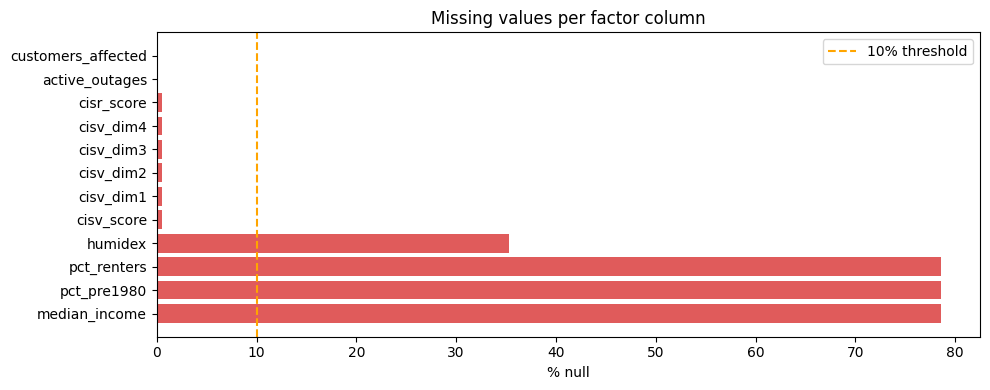

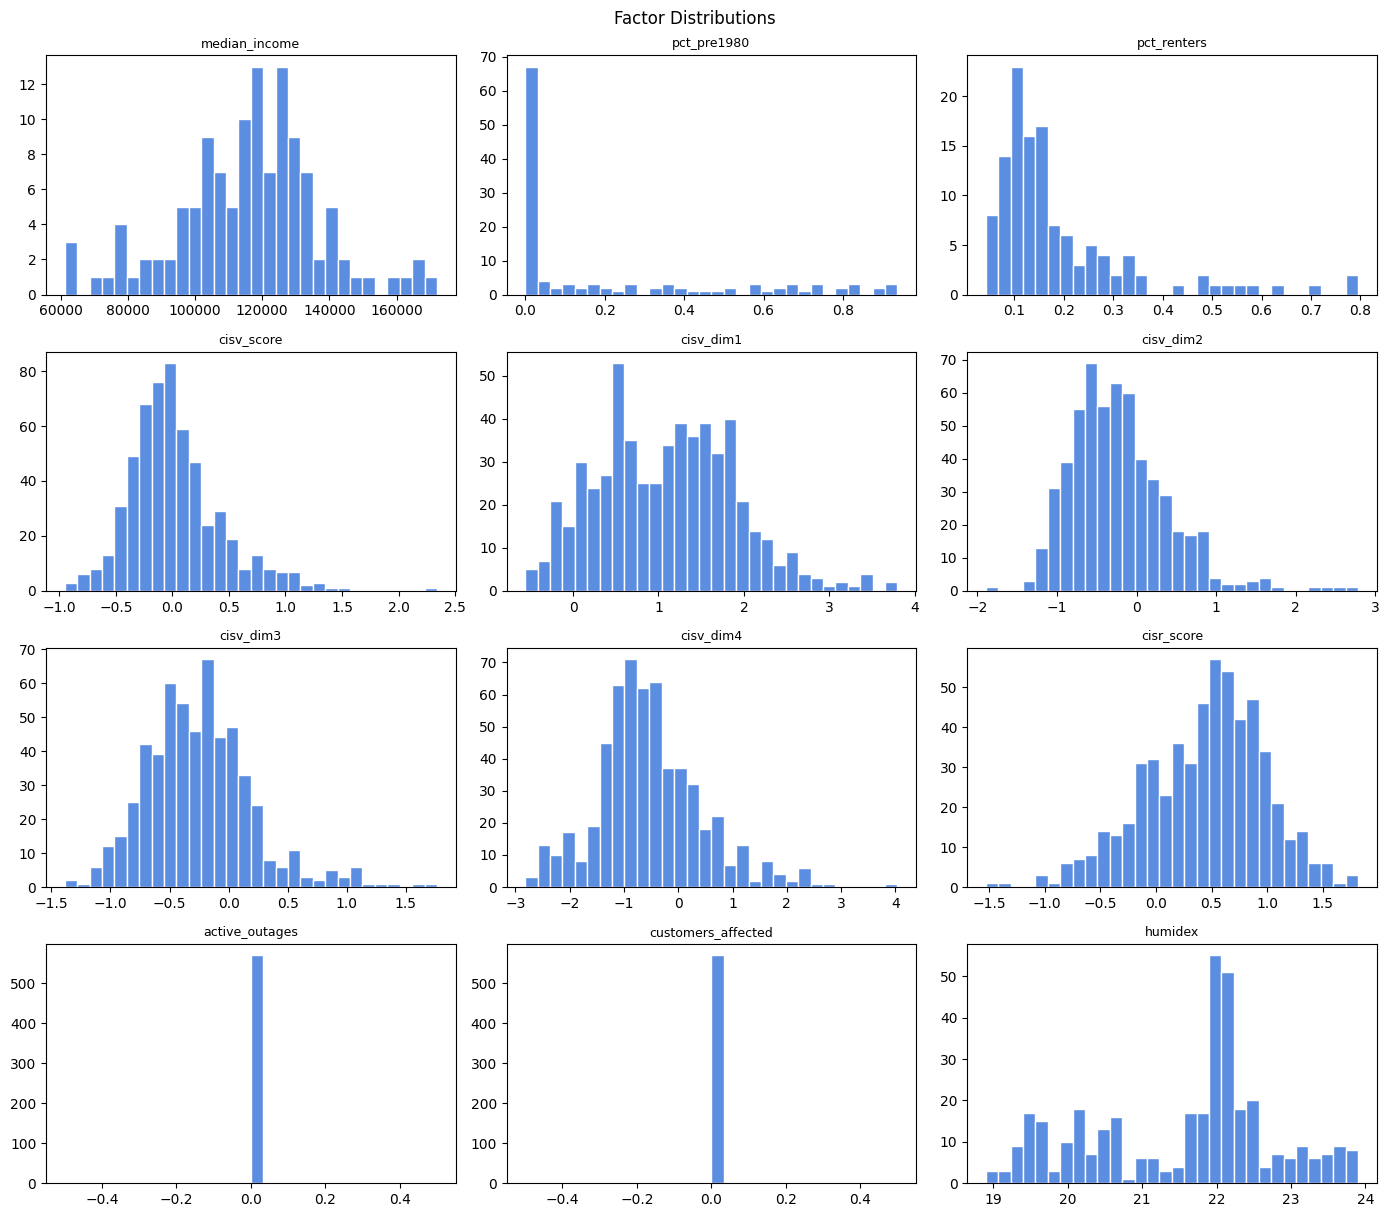

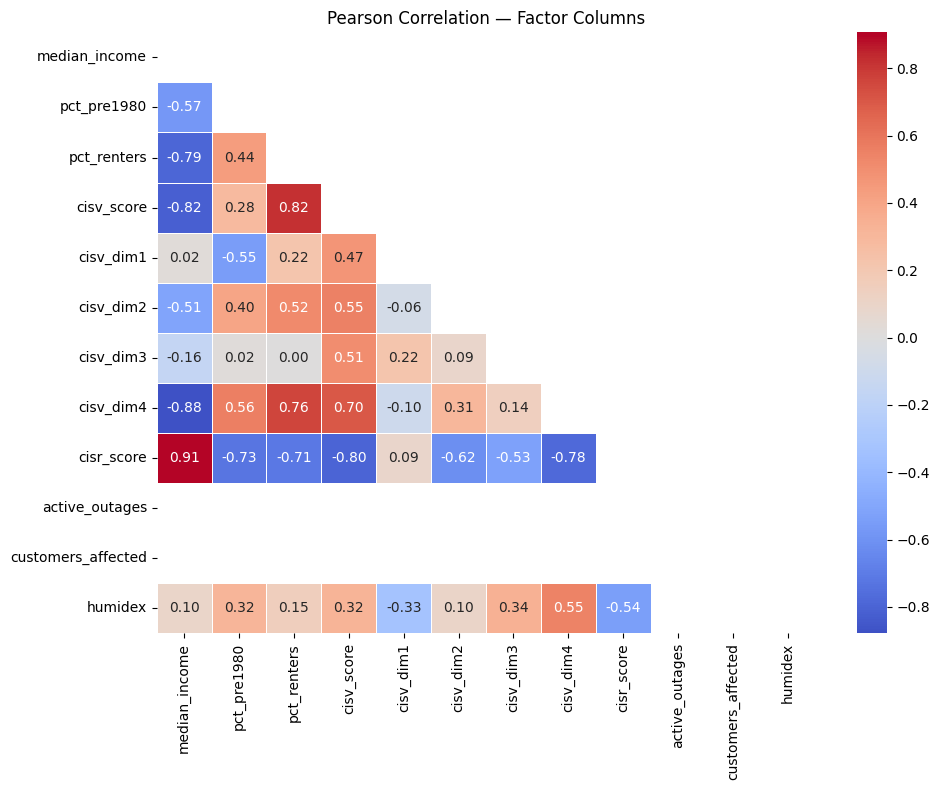


Factor summary stats:
       median_income  pct_pre1980  pct_renters  cisv_score  cisv_dim1  \
count         122.00       122.00       122.00      566.00     566.00   
mean       115822.95         0.21         0.19        0.02       1.09   
std         21206.59         0.29         0.15        0.41       0.80   
min         61200.00         0.00         0.04       -0.95      -0.56   
25%        103250.00         0.01         0.10       -0.24       0.49   
50%        118000.00         0.02         0.14       -0.04       1.09   
75%        128000.00         0.35         0.22        0.21       1.65   
max        172000.00         0.94         0.80        2.34       3.80   

       cisv_dim2  cisv_dim3  cisv_dim4  cisr_score  active_outages  \
count     566.00     566.00     566.00      566.00          569.00   
mean       -0.22      -0.25      -0.53        0.44            0.00   
std         0.62       0.46       0.97        0.54            0.00   
min        -1.89      -1.39      -2.82 

In [ ]:
# ── Section 3: Distributions & Data Quality ──────────────────────────────────

FACTOR_COLS = [
    "median_income", "pct_pre1980", "pct_renters",
    "cisv_score", "cisv_dim1", "cisv_dim2", "cisv_dim3", "cisv_dim4",
    "cisr_score",
    "active_outages", "customers_affected", "humidex",
]
available = [c for c in FACTOR_COLS if c in gdf_master.columns]
df_factors = gdf_master[available].copy()

# 3a: Missing value bar chart
null_pct = df_factors.isnull().mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(null_pct.index, null_pct.values * 100, color="#e05b5b")
ax.axvline(10, color="orange", linestyle="--", label="10% threshold")
ax.set_xlabel("% null"); ax.set_title("Missing values per factor column")
ax.legend(); plt.tight_layout(); plt.show()

# 3b: Factor histograms
cols_n = 3
rows_n = (len(available) + cols_n - 1) // cols_n
fig2, axes2 = plt.subplots(rows_n, cols_n, figsize=(14, rows_n * 3))
axes2 = axes2.flatten()
for i, col in enumerate(available):
    axes2[i].hist(df_factors[col].dropna(), bins=30, color="#5b8de0", edgecolor="white")
    axes2[i].set_title(col, fontsize=9)
for j in range(i + 1, len(axes2)):
    axes2[j].set_visible(False)
fig2.tight_layout()
fig2.suptitle("Factor Distributions", y=1.01, fontsize=12)
plt.show()

# 3c: Correlation matrix
corr = df_factors[available].corr()
fig3, ax3 = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, ax=ax3)
ax3.set_title("Pearson Correlation — Factor Columns")
plt.tight_layout(); plt.show()

print("\nFactor summary stats:")
print(df_factors[available].describe().round(3))


CTs retained after null filter: 566
⚠️  Dropping zero-variance columns: ['active_outages', 'customers_affected']


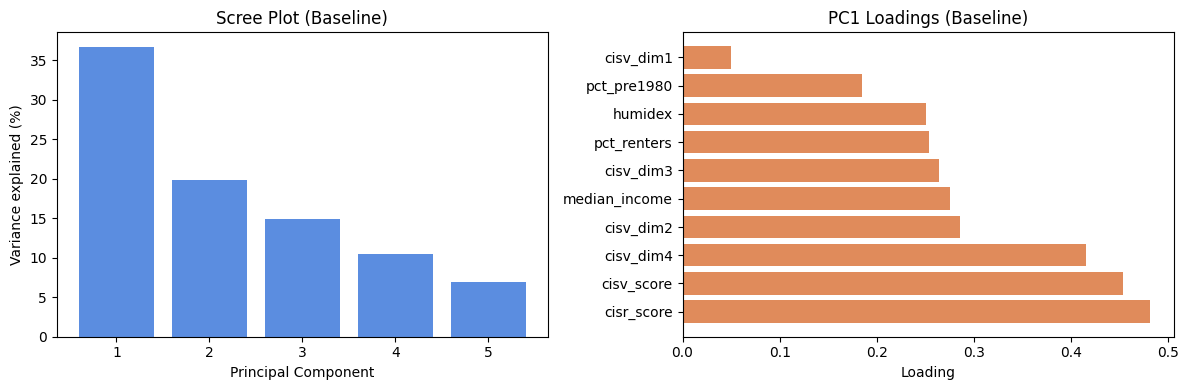

loadings.csv saved
Baseline PC1 explains: 36.7%


,factor,loading_baseline,loading_heatwave,loading_icestorm,source_slug
8,cisr_score,0.48,0.48,0.48,statcan-cisr-2021
3,cisv_score,0.45,0.45,0.45,statcan-cisv-2021
7,cisv_dim4,0.41,0.41,0.41,statcan-cisv-2021
5,cisv_dim2,0.29,0.29,0.29,statcan-cisv-2021
0,median_income,0.28,0.28,0.28,statcan-census-2021-ct-demographics
6,cisv_dim3,0.26,0.26,0.26,statcan-cisv-2021
2,pct_renters,0.25,0.25,0.25,statcan-census-2021-ct-demographics
9,humidex,0.25,0.25,0.25,envcan-geomet-current
1,pct_pre1980,0.19,0.19,0.19,statcan-census-2021-ct-demographics
4,cisv_dim1,0.05,0.05,0.05,statcan-cisv-2021


In [ ]:
# ── Section 4: PCA Threshold Score ───────────────────────────────────────────

FACTOR_COLS = [c for c in [
    "median_income", "pct_pre1980", "pct_renters",
    "cisv_score", "cisv_dim1", "cisv_dim2", "cisv_dim3", "cisv_dim4",
    "cisr_score",
    "active_outages", "customers_affected", "humidex",
] if c in gdf_master.columns]

df_pca = gdf_master[["CTUID"] + FACTOR_COLS].copy()

# Drop CTs missing >50% of factor columns
row_null_pct = df_pca[FACTOR_COLS].isnull().mean(axis=1)
df_pca = df_pca[row_null_pct <= 0.5].reset_index(drop=True)
print(f"CTs retained after null filter: {len(df_pca)}")

# Impute remaining NaN with column median; all-NaN columns get 0
medians = df_pca[FACTOR_COLS].median()
medians = medians.fillna(0)  # column is entirely NaN (e.g. no weather data) -> use 0
df_pca[FACTOR_COLS] = df_pca[FACTOR_COLS].fillna(medians)
# Drop any factor columns that remain all-zero (adds no signal to PCA)
zero_cols = [c for c in FACTOR_COLS if df_pca[c].std() == 0]
if zero_cols:
    print(f"⚠️  Dropping zero-variance columns: {zero_cols}")
    FACTOR_COLS = [c for c in FACTOR_COLS if c not in zero_cols]

# Invert income and cisr_score (higher resilience = lower vulnerability)
df_pca["median_income"] = -df_pca["median_income"]
if "cisr_score" in FACTOR_COLS:
    df_pca["cisr_score"] = -df_pca["cisr_score"]

SOURCE_MAP = {
    "median_income":    "statcan-census-2021-ct-demographics",
    "pct_pre1980":      "statcan-census-2021-ct-demographics",
    "pct_renters":      "statcan-census-2021-ct-demographics",
    "cisv_score":       "statcan-cisv-2021",
    "cisv_dim1":        "statcan-cisv-2021",
    "cisv_dim2":        "statcan-cisv-2021",
    "cisv_dim3":        "statcan-cisv-2021",
    "cisv_dim4":        "statcan-cisv-2021",
    "cisr_score":       "statcan-cisr-2021",
    "active_outages":   "alectra-outages-live",
    "customers_affected": "alectra-outages-live",
    "humidex":          "envcan-geomet-current",
}

def run_pca_scenario(df, factor_cols, weights: dict = None):
    """Normalize columns, apply optional weights, return (PCA, scores 0-100)."""
    X = df[factor_cols].copy()
    if weights:
        for col, w in weights.items():
            if col in X.columns:
                X[col] = X[col] * w
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    pca = PCA(n_components=min(5, len(factor_cols)))
    pca.fit(X_scaled)
    scores_raw = pca.transform(X_scaled)[:, 0]
    s_min, s_max = scores_raw.min(), scores_raw.max()
    scores_norm = (scores_raw - s_min) / (s_max - s_min) * 100
    return pca, scores_norm

# Baseline: equal weights
pca_baseline, scores_baseline = run_pca_scenario(df_pca, FACTOR_COLS)

# Heatwave: amplify heat/vulnerability factors
pca_heatwave, scores_heatwave = run_pca_scenario(
    df_pca, FACTOR_COLS,
    {"humidex": 2.5, "cimd_situational_vulnerability": 1.5, "pct_renters": 1.2}
)

# Ice Storm: amplify outage factors
pca_icestorm, scores_icestorm = run_pca_scenario(
    df_pca, FACTOR_COLS,
    {"active_outages": 3.0, "customers_affected": 2.0, "pct_renters": 1.5}
)

# Build scored GeoDataFrame
gdf_scored = gdf_master.merge(
    df_pca[["CTUID"]].assign(
        threshold_score_baseline=scores_baseline,
        threshold_score_heatwave=scores_heatwave,
        threshold_score_icestorm=scores_icestorm,
    ),
    on="CTUID", how="inner"
)

# Scree + loadings plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.bar(range(1, len(pca_baseline.explained_variance_ratio_) + 1),
        pca_baseline.explained_variance_ratio_ * 100, color="#5b8de0")
ax1.set_xlabel("Principal Component"); ax1.set_ylabel("Variance explained (%)")
ax1.set_title("Scree Plot (Baseline)")

loadings_df = pd.DataFrame({
    "factor":            FACTOR_COLS,
    "loading_baseline":  pca_baseline.components_[0],
    "loading_heatwave":  pca_heatwave.components_[0],
    "loading_icestorm":  pca_icestorm.components_[0],
    "source_slug":       [SOURCE_MAP.get(c, "unknown") for c in FACTOR_COLS],
}).sort_values("loading_baseline", key=abs, ascending=False)

ax2.barh(loadings_df["factor"], loadings_df["loading_baseline"], color="#e08b5b")
ax2.axvline(0, color="grey", linewidth=0.5)
ax2.set_title("PC1 Loadings (Baseline)"); ax2.set_xlabel("Loading")
plt.tight_layout(); plt.show()

loadings_df.to_csv(DATA_DIR / "loadings.csv", index=False)
print(f"loadings.csv saved")
print(f"Baseline PC1 explains: {pca_baseline.explained_variance_ratio_[0]:.1%}")
loadings_df


In [ ]:
# ASSERTION
assert "gdf_scored" in dir(), "gdf_scored not defined"
for col in ["threshold_score_baseline","threshold_score_heatwave","threshold_score_icestorm"]:
    assert col in gdf_scored.columns, f"Missing: {col}"
assert (DATA_DIR / "loadings.csv").exists(), "loadings.csv not written"
pc1_var = pca_baseline.explained_variance_ratio_[0]
assert pc1_var >= 0.15, f"PC1 explains only {pc1_var:.1%} — check factor columns"
print(f"✅ PCA assertions pass — PC1 explains {pc1_var:.1%} variance")
print(gdf_scored[["CTUID","threshold_score_baseline"]].describe())


✅ PCA assertions pass — PC1 explains 36.7% variance
       threshold_score_baseline
count                    566.00
mean                      36.99
std                       14.27
min                        0.00
25%                       27.38
50%                       34.54
75%                       44.87
max                      100.00


In [ ]:
# ── Save brampton_full.geojson ────────────────────────────────────────────────
# Filter to Brampton CTs only (5350528.xx – 5350577.xx range)
# Use df_census CTUID list as the authoritative Brampton CT set
brampton_ctuids = set(df_census["CTUID"].astype(str).tolist())
gdf_brampton = gdf_scored[gdf_scored["CTUID"].isin(brampton_ctuids)].copy()

# Add neighbourhood names
gdf_brampton["neighbourhood"] = gdf_brampton["CTUID"].map(neighbourhood_map).fillna("Brampton")

# Add risk level
def risk_level(score):
    if score >= 75: return "Critical"
    if score >= 50: return "High"
    if score >= 25: return "Moderate"
    return "Low"

gdf_brampton["risk_level"] = gdf_brampton["threshold_score_baseline"].apply(risk_level)
gdf_brampton["threshold_score"] = gdf_brampton["threshold_score_baseline"]

BRAMPTON_OUT = DATA_DIR / "brampton_full.geojson"
gdf_brampton.to_file(BRAMPTON_OUT, driver="GeoJSON")
print(f"brampton_full.geojson: {len(gdf_brampton)} CTs")
print(f"Columns: {gdf_brampton.columns.tolist()}")
print(f"Risk distribution:")
print(gdf_brampton["risk_level"].value_counts())


brampton_full.geojson: 122 CTs
Columns: ['CTUID', 'DGUID', 'CTNAME', 'LANDAREA', 'PRUID', 'geometry', 'cma_code', 'population', 'median_income', 'pct_renters', 'pct_pre1980', 'pct_low_income', 'cisv_score', 'cisv_dim1', 'cisv_dim2', 'cisv_dim3', 'cisv_dim4', 'cisv_quintile', 'cisr_score', 'cisr_dim1', 'cisr_dim2', 'cisr_dim3', 'cisr_quintile', 'served_by_alectra', 'active_outages', 'customers_affected', 'temperature_c', 'humidex', 'precipitation_mm', 'wind_speed_kmh', 'wind_gusts_kmh', 'weather_code', 'threshold_score_baseline', 'threshold_score_heatwave', 'threshold_score_icestorm', 'neighbourhood', 'risk_level', 'threshold_score']
Risk distribution:
risk_level
Moderate    83
High        18
Low         16
Critical     5
Name: count, dtype: int64


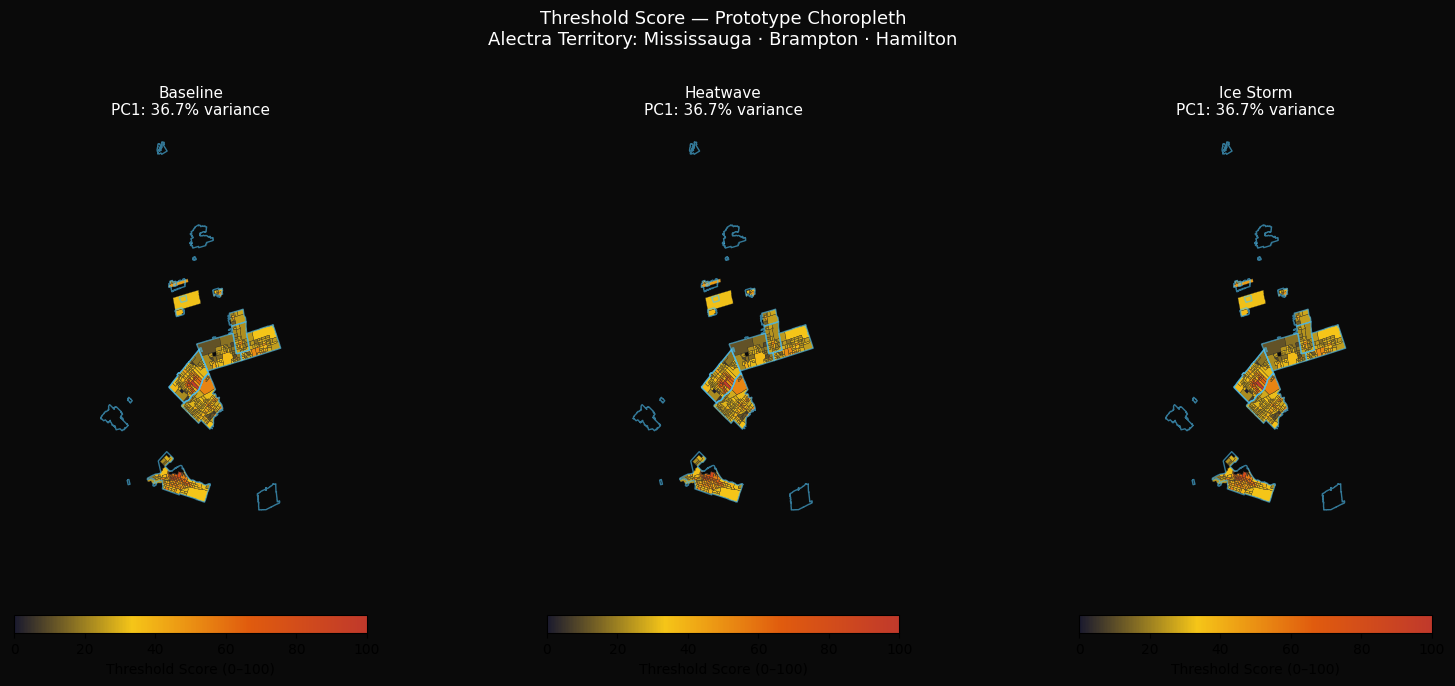

Saved prototype_choropleth.png


In [ ]:
# ── Section 5: Prototype Choropleth ──────────────────────────────────────────

CMAP = mcolors.LinearSegmentedColormap.from_list(
    "threshold", ["#1a1a2e", "#f5c518", "#e05b0e", "#c0392b"]
)

scenarios = [
    ("threshold_score_baseline", "Baseline"),
    ("threshold_score_heatwave",  "Heatwave"),
    ("threshold_score_icestorm",  "Ice Storm"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.patch.set_facecolor("#0a0a0a")

for ax, (score_col, title) in zip(axes, scenarios):
    ax.set_facecolor("#0a0a0a")
    if score_col not in gdf_scored.columns:
        ax.text(0.5, 0.5, f"{score_col}\nnot available",
                transform=ax.transAxes, ha="center", color="white")
        continue

    gdf_scored.plot(
        column=score_col, ax=ax, cmap=CMAP, vmin=0, vmax=100,
        linewidth=0.2, edgecolor="#333333",
        legend=True,
        legend_kwds={"shrink": 0.5, "label": "Threshold Score (0–100)",
                     "orientation": "horizontal"}
    )
    gdf_alectra.boundary.plot(ax=ax, color="#4fc3f7", linewidth=1.0, alpha=0.6)

    pca_obj = (pca_baseline if "baseline" in score_col
               else pca_heatwave if "heatwave" in score_col
               else pca_icestorm)
    pc_var = pca_obj.explained_variance_ratio_[0]
    ax.set_title(f"{title}\nPC1: {pc_var:.1%} variance", color="white", fontsize=11)
    ax.set_axis_off()

plt.suptitle("Threshold Score — Prototype Choropleth\n"
             "Alectra Territory: Mississauga · Brampton · Hamilton",
             color="white", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(DATA_DIR / "prototype_choropleth.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print("Saved prototype_choropleth.png")


In [ ]:
# ASSERTION
assert (DATA_DIR / "prototype_choropleth.png").exists(), "choropleth PNG not written"
print("✅ Choropleth written to pipeline/data/prototype_choropleth.png")


✅ Choropleth written to pipeline/data/prototype_choropleth.png


## Section 6 · Query from Postgres

The notebook above shows the *derivation*. The backend pipeline
(`python -m app.pipeline` from `backend/`) writes the same data into three
Postgres tables — `communities`, `facilities`, `pca_loadings` — and the
FastAPI service reads from there.

This section closes the loop: it connects to that database and shows that
the rows we'd just computed in the notebook match what the pipeline persists.


In [ ]:
# === DB-READ DEMO ===
# Requires THRESHOLD_DATABASE_URL to be set in the environment, pointing at
# the same Postgres the backend uses. Skipped gracefully when absent so the
# notebook can still run as a self-contained exploration.

import os
from sqlalchemy import create_engine, text

DB_URL = os.getenv("THRESHOLD_DATABASE_URL", "").replace("+asyncpg", "")
if not DB_URL:
    print("THRESHOLD_DATABASE_URL not set — skip DB-read demo.")
else:
    engine = create_engine(DB_URL, future=True)
    with engine.connect() as conn:
        df_db_communities = pd.read_sql(
            text("SELECT ctuid, properties, geometry, built_at FROM communities ORDER BY ctuid"),
            conn,
        )
        df_db_facilities = pd.read_sql(
            text("SELECT id, properties, built_at FROM facilities ORDER BY id"),
            conn,
        )
        df_db_loadings = pd.read_sql(
            text(
                "SELECT factor, loading_baseline, loading_heatwave, loading_icestorm,"
                " source_slug, built_at FROM pca_loadings ORDER BY abs(loading_baseline) DESC"
            ),
            conn,
        )
    print(f"communities: {len(df_db_communities)} rows")
    print(f"facilities:  {len(df_db_facilities)} rows")
    print(f"loadings:    {len(df_db_loadings)} rows")
    df_db_loadings


In [ ]:
# Pick one CT and show the round-trip: notebook-computed vs DB-stored.
if "df_db_communities" in dir() and len(df_db_communities) > 0:
    sample_ctuid = df_db_communities["ctuid"].iloc[0]
    db_row = df_db_communities[df_db_communities["ctuid"] == sample_ctuid].iloc[0]
    nb_row = gdf_brampton[gdf_brampton["CTUID"] == sample_ctuid].iloc[0]
    print(f"CTUID {sample_ctuid}")
    print(f"  notebook threshold_score_baseline: {nb_row['threshold_score_baseline']:.2f}")
    print(f"  db       threshold_score_baseline: {db_row['properties'].get('threshold_score_baseline'):.2f}")
else:
    print("Run the DB-read cell first (or populate the DB via `python -m app.pipeline`).")
